<a href="https://colab.research.google.com/github/VitorGama10/Portf-lio/blob/main/Possiveis_Vendas_Carros.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisando
## objetivo é ver possiveis vendas! 💰

In [34]:
!pip install graphviz==0.11

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [35]:
from sklearn.svm import LinearSVC
import numpy as np 
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [36]:
import pandas as pd

uri = "https://gist.githubusercontent.com/guilhermesilveira/e99a526b2e7ccc6c3b70f53db43a87d2/raw/1605fc74aa778066bf2e6695e24d53cf65f2f447/machine-learning-carros-simulacao.csv"
dados = pd.read_csv(uri).drop(columns=["Unnamed: 0"], axis=1)
dados

,preco,vendido,idade_do_modelo,km_por_ano
0,30941.02,1,18,35085.22134
1,40557.96,1,20,12622.05362
2,89627.50,0,12,11440.79806
3,95276.14,0,3,43167.32682
4,117384.68,1,4,12770.11290
...,...,...,...,...
9995,97112.86,0,12,25060.64248
9996,107424.63,1,16,21317.31764
9997,93856.99,0,4,20950.38812
9998,51250.57,1,7,16840.13376


In [37]:
dados = dados.sort_values('preco')
dados.index = range(dados.shape[0])
dados

,preco,vendido,idade_do_modelo,km_por_ano
0,-840.36,1,20,21367.20718
1,-270.77,1,20,27358.78000
2,1757.97,1,19,14664.30608
3,2789.88,1,20,19049.75758
4,3597.10,1,18,28699.36022
...,...,...,...,...
9995,117226.79,1,15,12940.70294
9996,117384.68,1,4,12770.11290
9997,118225.56,1,11,17459.72966
9998,118683.88,0,11,19641.99470


## Idade dos modelos 🚗
### Total de modelos

In [38]:
estatistica = dados[['idade_do_modelo']].value_counts().to_frame().reset_index()
estatistica.columns = ['idade_do_modelo', 'total'] 
estatistica

,idade_do_modelo,total
0,20,1011
1,19,912
2,18,888
3,17,810
4,16,769
5,15,685
6,14,668
7,12,625
8,13,618
9,11,544


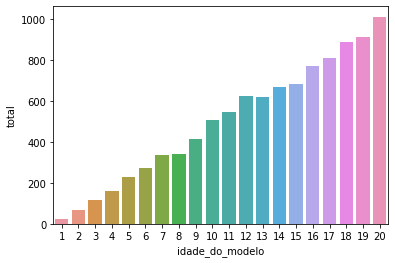

In [39]:
sns.barplot(x='idade_do_modelo', y='total', data=estatistica)

### Quantos foi vendido  💰

In [40]:
total = dados.vendido.value_counts().to_frame().reset_index()
total.columns = ['vendido', 'total'] ## trocando nome da coluna          
#1 == vendido
#0 === nao_vendido

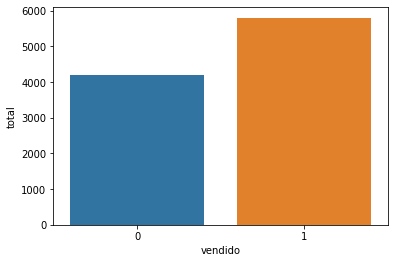

In [41]:
sns.barplot(x='vendido', y='total', data=total)

In [42]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   preco            10000 non-null  float64
 1   vendido          10000 non-null  int64  
 2   idade_do_modelo  10000 non-null  int64  
 3   km_por_ano       10000 non-null  float64
dtypes: float64(2), int64(2)
memory usage: 312.6 KB


In [43]:
x = dados [['preco', 'idade_do_modelo', 'km_por_ano']] #treino_x, teste_x
y = dados ['vendido'] #treino_y, teste_y

#### Treina os modelos 🥱

In [44]:
# ordem
treino_x, teste_x, treino_y, teste_y = train_test_split(x, y, test_size = 0.25, stratify = y)
print('Vou treinar %d Elementos e vou testar %d' % (len(treino_x), len(teste_x)))

Vou treinar 7500 Elementos e vou testar 2500


In [45]:
SEED = 30
np.random.seed(SEED)

modelo = LinearSVC()
modelo.fit(treino_x, treino_y) # Treinou os modelos

previsoes = modelo.predict(teste_x) # Previsoes

acuracia = accuracy_score(previsoes, teste_y) * 100

print('A Acuracia foi %.2f%%' % acuracia)


A Acuracia foi 61.92%


/usr/local/lib/python3.7/dist-packages/sklearn/svm/_base.py:1208: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  ConvergenceWarning,


## DecisionTreeClassifier
### Arvore de Decisão!!

In [46]:
SEED = 5
np.random.seed(SEED)
raw_treino_x, raw_teste_x, treino_y, teste_y = train_test_split(x, y, test_size = 0.25,
                                                       stratify = y)
print('Vou treinar %d Elementos e vou testar %d' % (len(treino_x), len(teste_x)))

Vou treinar 7500 Elementos e vou testar 2500


In [47]:
scaler = StandardScaler() # vai tira a media, deslocar todo mundo pela a media depois dividir pelo desvio padrao
scaler.fit(raw_treino_x)
treino_x = scaler.transform(raw_treino_x)
teste_x = scaler.transform(raw_teste_x)

modelo = DecisionTreeClassifier(max_depth = 3)
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

acuracia = accuracy_score(previsoes, teste_y) *100
print('A acuracia foi %.2f%%' % acuracia)

A acuracia foi 79.16%


## Arvore de Decisão !! 
### Possiveis vendas 🔥

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

SEED = 5
np.random.seed(SEED)
raw_treino_x, raw_teste_x, treino_y, teste_y = train_test_split(x, y, test_size = 0.25,
                                                         stratify = y)
print("Treinaremos com %d elementos e testaremos com %d elementos" % (len(treino_x), len(teste_x)))

modelo = DecisionTreeClassifier(max_depth=3)
modelo.fit(raw_treino_x, treino_y)
previsoes = modelo.predict(raw_teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print("A acurácia foi %.2f%%" % acuracia)

Treinaremos com 7500 elementos e testaremos com 2500 elementos
A acurácia foi 79.16%


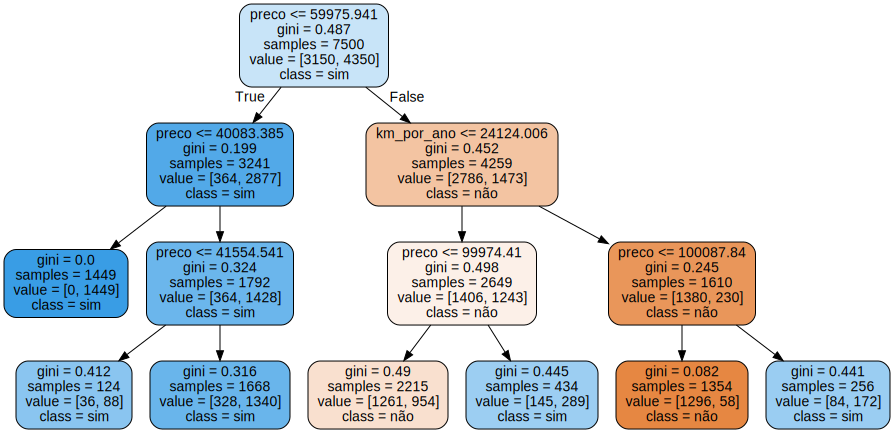

In [49]:
from sklearn.tree import export_graphviz
import graphviz

features = x.columns
dot_data = export_graphviz(modelo, out_file=None,
                           filled = True, rounded = True, ## cor
                           feature_names = features, class_names = ["não", "sim"]) # mudo o nome 
grafico = graphviz.Source(dot_data) # arvore
grafico

In [50]:
scaler = StandardScaler() # vai tira a media, deslocar todo mundo pela a media depois dividir pelo desvio padrao
scaler.fit(raw_treino_x)
treino_x = scaler.transform(raw_treino_x)
teste_x = scaler.transform(raw_teste_x)

modelo = DecisionTreeClassifier(max_depth = 3)
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

acuracia = accuracy_score(previsoes, teste_y) *100
print('A acuracia foi %.2f%%' % acuracia)

A acuracia foi 79.16%
